# Therapy Simulations

This notebook runs therapy simulations for the evolving-neighborhood ESS model and generates the main treatment-response panels used in this project.

## Goals
- define a consistent parameter set for therapy runs
- simulate treatment responses across a range of resource-sharing values `q`
- generate summary panels for:
  - a multi-`q` therapy time-course figure
  - an anti-angiogenic dose sweep
  - an anti-GLUT dose sweep

## Notes
This notebook is written to run top-to-bottom in one pass. The first code cell sets up imports, plotting defaults, and output folders used throughout the rest of the notebook.


In [5]:
# Imports and notebook setup
from pathlib import Path
import os
import sys

# Make matplotlib use a writable config directory.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Locate the project root so the local utils package can be imported.
# This makes the notebook more robust when run from Jupyter, VS Code,
# or after being moved into the project repository.
# ------------------------------------------------------------------
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/mnt/data"),
]

PROJECT_ROOT = None
for root in candidate_roots:
    if (root / "utils").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find a project root containing a 'utils' folder. "
        "Place this notebook in the project repository root (or one level below it)."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.models_therapy import integrate_ess
from utils.model_params import evolving_defaults, apply_overrides, to_dict

# -----------------------------
# Plot styling
# -----------------------------
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["savefig.transparent"] = False
mpl.rcParams["path.simplify"] = True

plt.rcParams.update({
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

# -----------------------------
# Output locations
# -----------------------------
OUT_DIR = Path("outputs/evolving_neighborhoods/therapy/ESS_dynamics")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUT_DIR.resolve()}")

Project root: C:\Users\80019048\Projects\vegf-glut1-coadaptation
Output directory: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\evolving_neighborhoods\therapy\ESS_dynamics


## Global therapy parameters

This section defines the baseline parameter set used for therapy simulations. These values serve as the shared defaults for the figures below, while individual cells override specific settings such as treatment strength or simulation horizon when needed.


In [2]:
# -----------------------------
# Model parameters
# -----------------------------
p_ESS = evolving_defaults()
p_ESS = apply_overrides(
    p_ESS,
    t_max=100000.0,      # simulation horizon
    e=1.0,
    d=1.0,               # therapy efficacy scalars
    m_G=0.0,
    m_A=10.0,            # default Figure 1 mode: anti-angiogenic
    sigma_u=0.9,
    sigma_y=0.9,
    b=0.8,
)

# Therapy start time (set to None to disable)
t_drug = 10000.0

# Resource sharing sweep
q_vals = [0.1, 0.3, 0.5, 0.7, 0.9]

# Initial conditions
N0, u0, y0 = 5.0, 0.5, 0.5


# -----------------------------
# Plot styling (publication / SVG friendly)
# -----------------------------
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["savefig.transparent"] = False
mpl.rcParams["path.simplify"] = True

plt.rcParams.update({
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})


# -----------------------------
# Shared helper functions
# -----------------------------
def _finite(x):
    """Return only the finite entries of an array-like input."""
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]


def _last_finite(x):
    """Return the last finite value in a trajectory."""
    x = _finite(x)
    return float(x[-1])


def compute_no_therapy_ic(q, p_base, eqb_tmax, N0=5.0, u0=0.5, y0=0.5):
    """Compute a no-therapy equilibrium to use as the therapy initial condition."""
    p_eqb = apply_overrides(p_base, t_max=float(eqb_tmax), m_A=0.0, m_G=0.0)
    res0 = integrate_ess(q=q, p=p_eqb, N0=N0, u0=u0, y0=y0, t_drug=None)
    return _last_finite(res0["N"]), _last_finite(res0["u"]), _last_finite(res0["y"])


def shade_for_index(j, cmap, n):
    """Choose progressively darker shades from a colormap."""
    return cmap(0.25 + 0.70 * (j / max(1, n - 1)))


def ylims_postdrug(t_list, z_list, t_drug, ignore_after, pad_frac=0.06):
    """Compute y-limits from post-drug dynamics while preserving the starting point."""
    vals = []

    for t, z in zip(t_list, z_list):
        t = np.asarray(t, dtype=float)
        z = np.asarray(z, dtype=float)
        n = min(len(t), len(z))
        t = t[:n]
        z = z[:n]

        if n > 0 and np.isfinite(z[0]):
            vals.append(z[0:1])

        if (t_drug is not None) and (ignore_after is not None) and (ignore_after > 0):
            mask = t >= (t_drug + ignore_after)
        else:
            mask = np.ones_like(t, dtype=bool)

        z_use = _finite(z[mask])
        if len(z_use):
            vals.append(z_use)

    if not vals:
        return (0.0, 1.0)

    zcat = np.concatenate(vals)
    zmax = float(np.max(zcat))
    if (not np.isfinite(zmax)) or (zmax <= 0):
        return (0.0, 1.0)

    return (0.0, zmax * (1.0 + pad_frac))


## Figure 1. ESS therapy dynamics across a sweep of resource sharing values

For each value of `q`, this section first computes a no-therapy equilibrium to use as the treatment initial condition, then simulates the therapy-on trajectory and plots `N(t)`, `u(t)`, and `y(t)`.

This figure is intended to be run in **two versions**:

1. **Anti-angiogenic panel:** set `m_A = 10` and `m_G = 0`
2. **Anti-GLUT panel:** set `m_G = 10` and `m_A = 0`

The code cell below includes a small label variable so that the exported figure and Excel workbook names update automatically depending on which treatment mode is being plotted.

This cell also exports:
- a multi-panel figure
- an Excel workbook containing one sheet per `q`
- a metadata sheet with the parameter values used


[ICs] q=0.1  N0=29.8123  u0=258.539  y0=56.3153
[ICs] q=0.3  N0=66.1921  u0=90.1345  y0=40.4329
[ICs] q=0.5  N0=139.472  u0=25.6643  y0=25.535
[ICs] q=0.7  N0=240.374  u0=6.45358  y0=14.6482
[ICs] q=0.9  N0=355.306  u0=0.812185  y0=6.83259


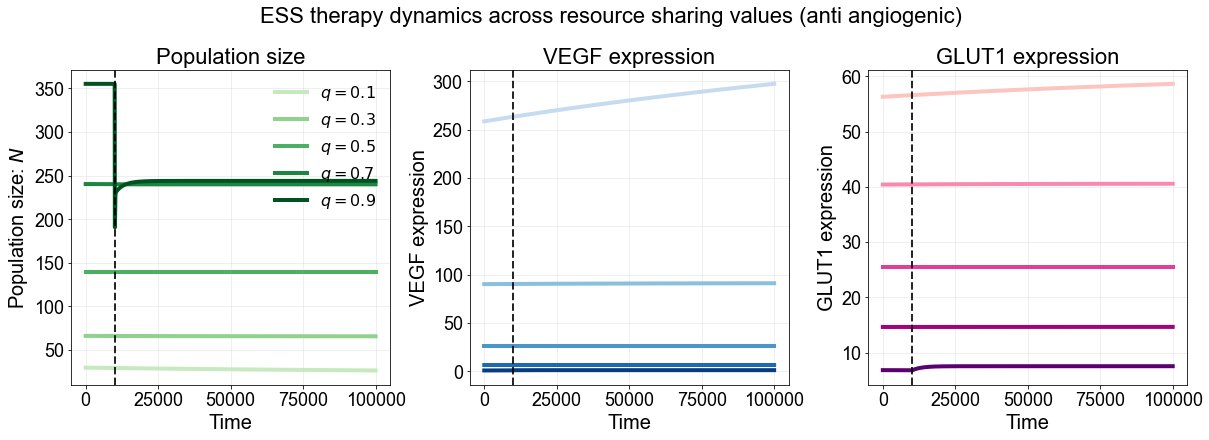

Saved Figure 1 outputs with stem: therapy_ESS_qpanel_eqbIC_anti_angiogenic


In [3]:
# =========================
# Therapy: Evolving-neighborhood ESS panels (q sweep)
# with ICs = no-therapy equilibrium (q-specific)
#
# Run this cell twice to generate the two treatment panels:
#   1) Anti-angiogenic: m_A = 10, m_G = 0
#   2) Anti-GLUT:       m_G = 10, m_A = 0
#
# The exported filenames update automatically based on the
# treatment label chosen below.
# =========================

# -----------------------------
# Choose the Figure 1 treatment mode
# -----------------------------
treatment_label = "anti_angiogenic"   # or "anti_GLUT"

if treatment_label == "anti_angiogenic":
    fig1_mA, fig1_mG = 10.0, 0.0
elif treatment_label == "anti_GLUT":
    fig1_mA, fig1_mG = 0.0, 10.0
else:
    raise ValueError("treatment_label must be 'anti_angiogenic' or 'anti_GLUT'.")

fig_stem = f"therapy_ESS_qpanel_eqbIC_{treatment_label}"
xlsx_out = OUT_DIR / f"{fig_stem}_data.xlsx"

# -----------------------------
# Model parameters + sweep config
# -----------------------------
p_ESS = evolving_defaults()
p_ESS = apply_overrides(
    p_ESS,
    t_max=100000.0,
    e=1.0,
    d=1.0,
    m_G=fig1_mG,
    m_A=fig1_mA,
    sigma_u=0.8,
    sigma_y=0.8,
)

# If you want the no-therapy equilibration to run longer, increase this:
p_eqb = apply_overrides(p_ESS, t_max=200000.0)

t_drug = 10000.0
q_vals = [0.1, 0.3, 0.5, 0.7, 0.9]

# -----------------------------
# Styling / colormaps
# -----------------------------
cmap_N = cm.get_cmap("Greens")
cmap_u = cm.get_cmap("Blues")
cmap_y = cm.get_cmap("RdPu")

# -----------------------------
# Compute no-therapy equilibrium ICs for each q
# -----------------------------
init_by_q = {}
for q in q_vals:
    Nq, uq, yq = compute_no_therapy_ic(q=q, p_base=p_ESS, eqb_tmax=p_eqb.t_max, N0=N0, u0=u0, y0=y0)
    init_by_q[q] = {"N0": Nq, "u0": uq, "y0": yq}
    print(f"[ICs] q={q:.1f}  N0={Nq:.6g}  u0={uq:.6g}  y0={yq:.6g}")

# -----------------------------
# Run therapy simulations
# -----------------------------
results = {}
for q in q_vals:
    ic = init_by_q[q]
    res = integrate_ess(
        q=q,
        p=p_ESS,
        N0=ic["N0"],
        u0=ic["u0"],
        y0=ic["y0"],
        t_drug=t_drug,
    )
    results[q] = res

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 5.8), sharex=True)
fig.subplots_adjust(wspace=0.25)

for i, q in enumerate(q_vals):
    color_N = shade_for_index(i, cmap_N, len(q_vals))
    color_u = shade_for_index(i, cmap_u, len(q_vals))
    color_y = shade_for_index(i, cmap_y, len(q_vals))

    t = results[q]["t"]
    N = results[q]["N"]
    u = results[q]["u"]
    y = results[q]["y"]

    axes[0].plot(t, N, lw=4, color=color_N, label=rf"$q={q}$")
    axes[1].plot(t, u, lw=4, color=color_u, label=rf"$q={q}$")
    axes[2].plot(t, y, lw=4, color=color_y, label=rf"$q={q}$")

for ax, title, ylabel in zip(
    axes,
    ["Population size", "VEGF expression", "GLUT1 expression"],
    [r"Population size: $N$", "VEGF expression", "GLUT1 expression"],
):
    ax.axvline(t_drug, color="k", lw=2.0, ls="--", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)

axes[0].legend(frameon=False, loc="best")
fig.suptitle(f"ESS therapy dynamics across resource sharing values ({treatment_label.replace('_', ' ')})", y=1.03, fontsize=22)

# -----------------------------
# Save figure
# -----------------------------
for ext in ["png", "svg", "pdf"]:
    fig.savefig(OUT_DIR / f"{fig_stem}.{ext}", dpi=300, bbox_inches="tight")

plt.show()

# -----------------------------
# Export trajectories + metadata
# -----------------------------
with pd.ExcelWriter(xlsx_out, engine="openpyxl") as writer:
    for q in q_vals:
        res = results[q]
        df_q = pd.DataFrame({
            "t": res["t"],
            "N": res["N"],
            "u": res["u"],
            "y": res["y"],
        })
        df_q.to_excel(writer, sheet_name=f"q_{str(q).replace('.', 'p')}", index=False)

    metadata = pd.DataFrame([
        {
            "treatment_label": treatment_label,
            "m_A": fig1_mA,
            "m_G": fig1_mG,
            "t_drug": t_drug,
            **to_dict(p_ESS),
        }
    ])
    metadata.to_excel(writer, sheet_name="params", index=False)

    ic_df = pd.DataFrame([
        {"q": q, **init_by_q[q]} for q in q_vals
    ])
    ic_df.to_excel(writer, sheet_name="initial_conditions", index=False)

print(f"Saved Figure 1 outputs with stem: {fig_stem}")


## Figure 2. Anti-angiogenic dose sweep

This section fixes `m_G = 0` and varies anti-angiogenic treatment strength `m_A` across three representative resource-sharing values: low (`q = 0.1`), intermediate (`q = 0.5`), and high (`q = 0.9`).

The helper functions used here are defined earlier in the notebook so that this section does not need to re-import modules or redefine utility functions.


[ICs] q=0.1  N0=21.4052  u0=383.656  y0=63.0195
[ICs] q=0.5  N0=139.472  u0=25.6643  y0=25.535
[ICs] q=0.9  N0=355.306  u0=0.812185  y0=6.83259


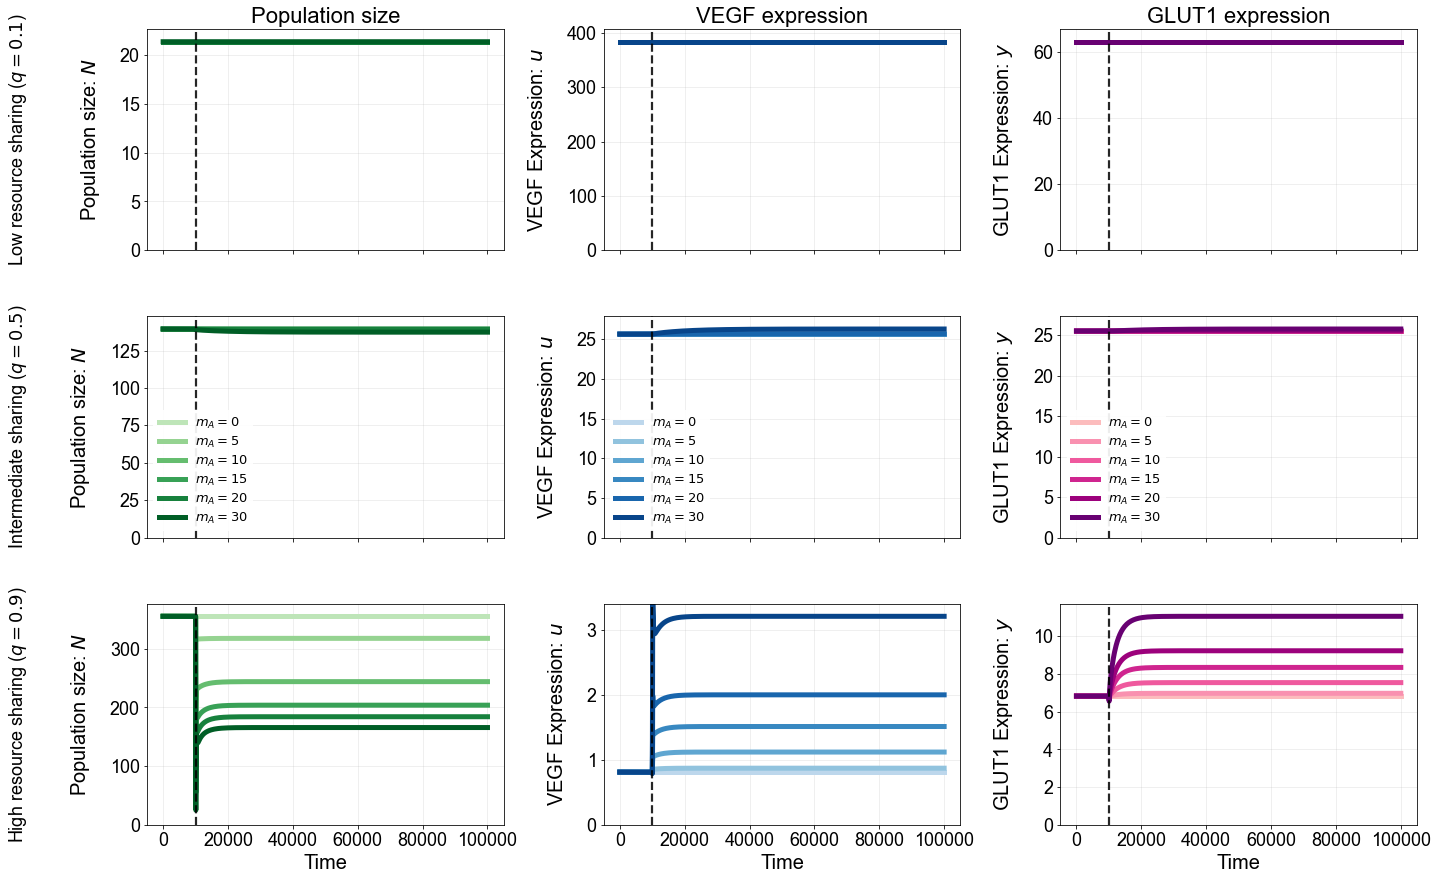

In [11]:
# ===============================
# Therapy: 3×3 panel (rows: q=0.1, 0.5, 0.9; cols: N, u, y)
# Anti-angiogenic sweep: mA varies, mG fixed
# ===============================

# ---------- Figure-specific configuration ----------
q_rows = [0.1, 0.5, 0.9]
t_drug = 10000.0

mA_list = [0, 5, 10, 15, 20, 30]
mG_fixed = 0.0

# Converged no-therapy ICs
eqb_tmax = 8e6
eqb_sigma = 0.9
eqb_b = 1.0

# Therapy-run horizon
therapy_t_max = 100000.0

# Ignore an early post-drug transient when computing y-limits
ignore_window_after_drug = 5000.0

# ---------- Base params ----------
p_base = evolving_defaults()
p_base = apply_overrides(p_base, sigma_u=eqb_sigma, sigma_y=eqb_sigma, b=eqb_b)

# ---------- ICs per q ----------
init_by_q = {}
for q in q_rows:
    N0, u0, y0 = compute_no_therapy_ic(q=q, p_base=p_base, eqb_tmax=eqb_tmax)
    init_by_q[q] = dict(N0=N0, u0=u0, y0=y0)
    print(f"[ICs] q={q:.1f}  N0={N0:.6g}  u0={u0:.6g}  y0={y0:.6g}")

# ---------- Colormaps ----------
cmap_N = cm.get_cmap("Greens")
cmap_U = cm.get_cmap("Blues")
cmap_Y = cm.get_cmap("RdPu")

LW = 5.0
nC = len(mA_list)

# ---------- Run simulations ----------
p_run_base = apply_overrides(p_base, t_max=float(therapy_t_max))
data = []
for q in q_rows:
    N0, u0, y0 = init_by_q[q]["N0"], init_by_q[q]["u0"], init_by_q[q]["y0"]

    row = {"q": q, "t": [], "N": [], "u": [], "y": []}
    for mA in mA_list:
        p_run = apply_overrides(p_run_base, m_A=float(mA), m_G=float(mG_fixed))
        res = integrate_ess(q=q, p=p_run, N0=N0, u0=u0, y0=y0, t_drug=t_drug)

        row["t"].append(np.asarray(res["t"], dtype=float))
        row["N"].append(np.asarray(res["N"], dtype=float))
        row["u"].append(np.asarray(res["u"], dtype=float))
        row["y"].append(np.asarray(res["y"], dtype=float))
    data.append(row)

# ---------- Column-specific legend handles ----------
legend_labels = [rf"$m_A={mA:g}$" for mA in mA_list]
legend_handles_N = [
    Line2D([0], [0], color=shade_for_index(j, cmap_N, nC), lw=LW, label=legend_labels[j])
    for j in range(nC)
]
legend_handles_U = [
    Line2D([0], [0], color=shade_for_index(j, cmap_U, nC), lw=LW, label=legend_labels[j])
    for j in range(nC)
]
legend_handles_Y = [
    Line2D([0], [0], color=shade_for_index(j, cmap_Y, nC), lw=LW, label=legend_labels[j])
    for j in range(nC)
]

# ---------- Plot ----------
fig, axes = plt.subplots(3, 3, figsize=(21, 13), sharex="col")
fig.subplots_adjust(left=0.14, right=0.98, top=0.93, bottom=0.08, wspace=0.28, hspace=0.30)

axes[0, 0].set_title("Population size")
axes[0, 1].set_title("VEGF expression")
axes[0, 2].set_title("GLUT1 expression")

for i, row in enumerate(data):
    q = row["q"]
    axN, axU, axY = axes[i]

    for j, mA in enumerate(mA_list):
        t = row["t"][j]
        N = row["N"][j]
        u = row["u"][j]
        y = row["y"][j]

        axN.plot(t, N, color=shade_for_index(j, cmap_N, nC), lw=LW)
        axU.plot(t, u, color=shade_for_index(j, cmap_U, nC), lw=LW)
        axY.plot(t, y, color=shade_for_index(j, cmap_Y, nC), lw=LW)

    axN.set_ylim(*ylims_postdrug(row["t"], row["N"], t_drug, ignore_window_after_drug))
    axU.set_ylim(*ylims_postdrug(row["t"], row["u"], t_drug, ignore_window_after_drug))
    axY.set_ylim(*ylims_postdrug(row["t"], row["y"], t_drug, ignore_window_after_drug))

    for ax in (axN, axU, axY):
        ax.axvline(t_drug, color="k", lw=2.2, ls="--", alpha=0.85)
        ax.grid(True, alpha=0.25)
        ax.set_axisbelow(True)

    row_text = (
        r"Low resource sharing ($q=0.1$)" if np.isclose(q, 0.1) else
        r"Intermediate sharing ($q=0.5$)" if np.isclose(q, 0.5) else
        r"High resource sharing ($q=0.9$)"
    )
    axN.text(-0.33, 0.5, row_text, transform=axN.transAxes,
             rotation=90, ha="right", va="center", fontsize=18)

for i in range(3):
    axes[i, 0].set_ylabel(r"Population size: $N$", labelpad=18)
    axes[i, 1].set_ylabel(r"VEGF Expression: $u$", labelpad=18)
    axes[i, 2].set_ylabel(r"GLUT1 Expression: $y$", labelpad=18)

for ax in axes[-1]:
    ax.set_xlabel("Time")

# Put legends only in the top row, but in all three columns.
legend_kw = dict(
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.92,
    fontsize=13,          # ↓ slightly smaller
    labelspacing=0.3,     # tighter vertical spacing
    handlelength=2.0
)

# Legends in middle row (row = 1), all columns
axes[1, 0].legend(handles=legend_handles_N, **legend_kw)
axes[1, 1].legend(handles=legend_handles_U, **legend_kw)
axes[1, 2].legend(handles=legend_handles_Y, **legend_kw)

plt.show()


## Figure 3. Anti-GLUT dose sweep

This section mirrors the previous figure but now fixes `m_A = 0` and varies anti-GLUT treatment strength `m_G`. The same three resource-sharing regimes are shown to make the comparison with anti-angiogenic therapy straightforward.

As in Figure 2, this cell relies on the shared imports, styling, and helper functions defined earlier in the notebook.


[ICs] q=0.1  N0=21.4052  u0=383.656  y0=63.0195
[ICs] q=0.5  N0=139.472  u0=25.6643  y0=25.535
[ICs] q=0.9  N0=355.306  u0=0.812185  y0=6.83259


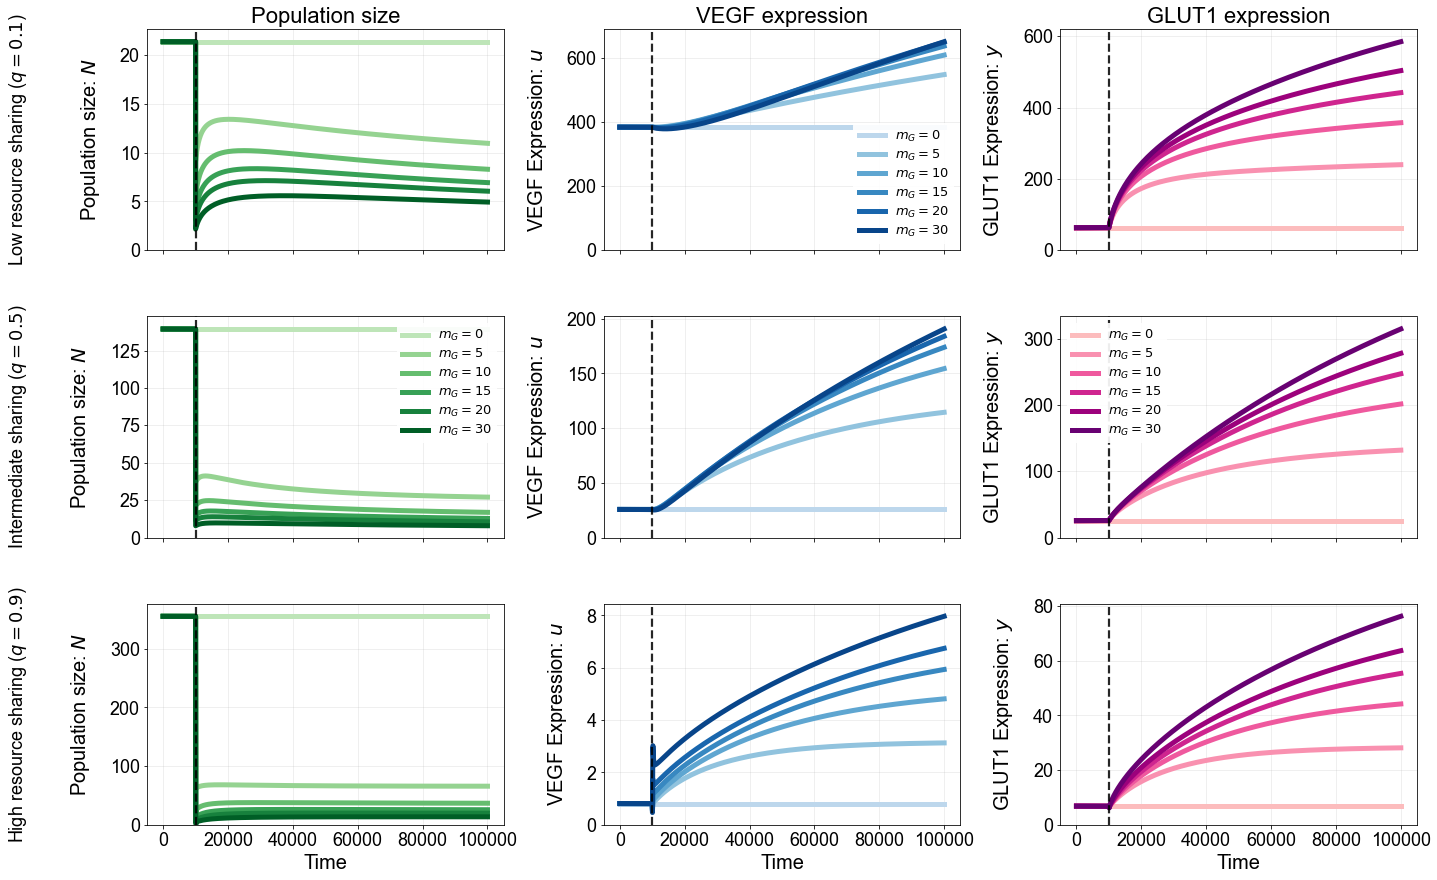

In [13]:
# ===============================
# Therapy: 3×3 panel (rows: q=0.1, 0.5, 0.9; cols: N, u, y)
# Anti-GLUT sweep: mG varies, mA fixed
# ===============================

# ---------- Figure-specific configuration ----------
q_rows = [0.1, 0.5, 0.9]
t_drug = 10000.0

mG_list = [0, 5, 10, 15, 20, 30]
mA_fixed = 0.0

# Converged no-therapy ICs
eqb_tmax = 8e6
eqb_sigma = 0.9
eqb_b = 1.0

# Therapy-run horizon
therapy_t_max = 100000.0

# Ignore an early post-drug transient when computing y-limits
ignore_window_after_drug = 5000.0

# ---------- Base params ----------
p_base = evolving_defaults()
p_base = apply_overrides(p_base, sigma_u=eqb_sigma, sigma_y=eqb_sigma, b=eqb_b)

# ---------- ICs per q ----------
init_by_q = {}
for q in q_rows:
    N0, u0, y0 = compute_no_therapy_ic(q=q, p_base=p_base, eqb_tmax=eqb_tmax)
    init_by_q[q] = dict(N0=N0, u0=u0, y0=y0)
    print(f"[ICs] q={q:.1f}  N0={N0:.6g}  u0={u0:.6g}  y0={y0:.6g}")

# ---------- Colormaps ----------
cmap_N = cm.get_cmap("Greens")
cmap_U = cm.get_cmap("Blues")
cmap_Y = cm.get_cmap("RdPu")

LW = 5.0
nC = len(mG_list)

# ---------- Run simulations ----------
p_run_base = apply_overrides(p_base, t_max=float(therapy_t_max))
data = []
for q in q_rows:
    N0, u0, y0 = init_by_q[q]["N0"], init_by_q[q]["u0"], init_by_q[q]["y0"]

    row = {"q": q, "t": [], "N": [], "u": [], "y": []}
    for mG in mG_list:
        p_run = apply_overrides(p_run_base, m_G=float(mG), m_A=float(mA_fixed))
        res = integrate_ess(q=q, p=p_run, N0=N0, u0=u0, y0=y0, t_drug=t_drug)

        row["t"].append(np.asarray(res["t"], dtype=float))
        row["N"].append(np.asarray(res["N"], dtype=float))
        row["u"].append(np.asarray(res["u"], dtype=float))
        row["y"].append(np.asarray(res["y"], dtype=float))
    data.append(row)

# ---------- Column-specific legend handles ----------
legend_labels = [rf"$m_G={mG:g}$" for mG in mG_list]
legend_handles_N = [
    Line2D([0], [0], color=shade_for_index(j, cmap_N, nC), lw=LW, label=legend_labels[j])
    for j in range(nC)
]
legend_handles_U = [
    Line2D([0], [0], color=shade_for_index(j, cmap_U, nC), lw=LW, label=legend_labels[j])
    for j in range(nC)
]
legend_handles_Y = [
    Line2D([0], [0], color=shade_for_index(j, cmap_Y, nC), lw=LW, label=legend_labels[j])
    for j in range(nC)
]

# ---------- Plot ----------
fig, axes = plt.subplots(3, 3, figsize=(21, 13), sharex="col")
fig.subplots_adjust(left=0.14, right=0.98, top=0.93, bottom=0.08, wspace=0.28, hspace=0.30)

axes[0, 0].set_title("Population size")
axes[0, 1].set_title("VEGF expression")
axes[0, 2].set_title("GLUT1 expression")

for i, row in enumerate(data):
    q = row["q"]
    axN, axU, axY = axes[i]

    for j, mG in enumerate(mG_list):
        t = row["t"][j]
        N = row["N"][j]
        u = row["u"][j]
        y = row["y"][j]

        axN.plot(t, N, color=shade_for_index(j, cmap_N, nC), lw=LW)
        axU.plot(t, u, color=shade_for_index(j, cmap_U, nC), lw=LW)
        axY.plot(t, y, color=shade_for_index(j, cmap_Y, nC), lw=LW)

    axN.set_ylim(*ylims_postdrug(row["t"], row["N"], t_drug, ignore_window_after_drug))
    axU.set_ylim(*ylims_postdrug(row["t"], row["u"], t_drug, ignore_window_after_drug))
    axY.set_ylim(*ylims_postdrug(row["t"], row["y"], t_drug, ignore_window_after_drug))

    for ax in (axN, axU, axY):
        ax.axvline(t_drug, color="k", lw=2.2, ls="--", alpha=0.85)
        ax.grid(True, alpha=0.25)
        ax.set_axisbelow(True)

    row_text = (
        r"Low resource sharing ($q=0.1$)" if np.isclose(q, 0.1) else
        r"Intermediate sharing ($q=0.5$)" if np.isclose(q, 0.5) else
        r"High resource sharing ($q=0.9$)"
    )
    axN.text(-0.33, 0.5, row_text, transform=axN.transAxes,
             rotation=90, ha="right", va="center", fontsize=18)

for i in range(3):
    axes[i, 0].set_ylabel(r"Population size: $N$", labelpad=18)
    axes[i, 1].set_ylabel(r"VEGF Expression: $u$", labelpad=18)
    axes[i, 2].set_ylabel(r"GLUT1 Expression: $y$", labelpad=18)

for ax in axes[-1]:
    ax.set_xlabel("Time")

# Put legends only in the top row, but in all three columns.
legend_kw = dict(
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.92,
    fontsize=13,          # ↓ slightly smaller
    labelspacing=0.3,     # tighter vertical spacing
    handlelength=2.0
)

# Custom placement:
# Green (N) → middle row, first column
axes[1, 0].legend(handles=legend_handles_N, loc ='upper right', **legend_kw)

# Blue (u) → first row, second column
axes[0, 1].legend(handles=legend_handles_U, loc ='lower right', **legend_kw)

# Pink (y) → middle row, third column
axes[1, 2].legend(handles=legend_handles_Y, loc ='upper left', **legend_kw)

plt.show()
